<a href="https://colab.research.google.com/github/FrancescoRosi01/Tesi/blob/experimental/LoadFromHuggingFace.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!git lfs install
!git clone https://huggingface.co/datasets/FrancescoRosi01/ds3


Git LFS initialized.
Cloning into 'ds3'...
remote: Enumerating objects: 1813, done.
remote: Counting objects: 100% (4/4), done.
remote: Compressing objects: 100% (3/3), done.
remote: Total 1813 (delta 0), reused 0 (delta 0), pack-reused 1809 (from 1)
Receiving objects: 100% (1813/1813), 264.06 KiB | 3.72 MiB/s, done.
Updating files: 100% (1809/1809), done.
Filtering content: 100% (1807/1807), 200.24 MiB | 3.04 MiB/s, done.


In [2]:
import tensorflow as tf
from tensorflow import keras
from google.colab import drive
import matplotlib.pyplot as plt
from pathlib import Path
import json
import numpy as np
import re
from sklearn.model_selection import train_test_split


def load_and_process_image(path, label):
    """ restituisce il tensore 3d (l'immagine) e la label associata al path che prende in input"""
    img_raw = tf.io.read_file(path)
    img = tf.io.decode_png(img_raw, channels=3)
    img = tf.image.resize(img, (224,224))
    # normalizzare
    img = img / 255.0
    return img, label

def load_ds(ds_path : Path):
    """ restituisce i dataset di training, validation e test"""
    imgs_path = ds_path / 'images'
    labels_path = ds_path / 'labels' / 'labels.json'
    with open(labels_path, 'r') as f:
        labels = json.load(f)
        labels = np.array(list(labels.values()))
        labels = labels.astype(np.float32)
    regex = re.compile(r"img_(\d+)\.png")
    # imgs_path è una lista ordinata di path delle immagini.
    imgs_path = sorted(
        map(lambda x:str(x),imgs_path.glob('img_*.png')),
        key=lambda x: int(regex.search(x).group(1))
        )
    train_paths, test_paths, train_labels, test_labels = train_test_split(imgs_path, labels, test_size=0.2, random_state=1)
    train_paths, val_paths, train_labels, val_labels = train_test_split(train_paths, train_labels, test_size=0.25, random_state=1)
    # train -> 60%, val -> 20%, test -> 20%
    train_ds = tf.data.Dataset.from_tensor_slices((train_paths,train_labels))
    val_ds = tf.data.Dataset.from_tensor_slices((val_paths,val_labels))
    test_ds = tf.data.Dataset.from_tensor_slices((test_paths,test_labels))
    BATCH_SZ = 32
    # load_and_process_image restituisce il tensore 3d (l'immagine) associata al path che prende in input
    train_ds = train_ds.map(load_and_process_image, num_parallel_calls=tf.data.AUTOTUNE)
    val_ds = val_ds.map(load_and_process_image, num_parallel_calls=tf.data.AUTOTUNE)
    test_ds = test_ds.map(load_and_process_image, num_parallel_calls=tf.data.AUTOTUNE)
    # Shuffle
    train_ds = train_ds.shuffle(buffer_size=1000)
    val_ds = val_ds.shuffle(buffer_size=1000)
    # Batch
    train_ds = train_ds.batch(BATCH_SZ)
    val_ds = val_ds.batch(BATCH_SZ)
    test_ds = test_ds.batch(BATCH_SZ)
    train_ds = train_ds.prefetch(buffer_size=tf.data.AUTOTUNE)
    val_ds = val_ds.prefetch(buffer_size=tf.data.AUTOTUNE)
    test_ds = test_ds.prefetch(buffer_size= tf.data.AUTOTUNE)
    return train_ds,val_ds,test_ds

In [3]:
train,val,test = load_ds(Path("ds3"))

In [4]:
for images, labels in train.take(1):
    print(f"Image batch shape: {images.shape}")
    print(f"Label batch shape: {labels.shape}")
    print(f"Sample label: {labels[0]}")

Image batch shape: (32, 224, 224, 3)
Label batch shape: (32,)
Sample label: 0.7833333611488342


In [5]:
model = keras.models.Sequential([
    keras.layers.Input(shape=(224,224,3)),

    keras.layers.Conv2D(32, (3,3), activation='relu'),
    keras.layers.MaxPooling2D((2,2)),

    keras.layers.Conv2D(64, (3,3), activation='relu'),
    keras.layers.MaxPooling2D((2,2)),

    keras.layers.Conv2D(128, (3, 3), activation='relu'),
    keras.layers.MaxPooling2D((2, 2)),

    keras.layers.Flatten(),
    keras.layers.Dense(64, activation='relu',kernel_initializer="he_normal"),
    keras.layers.Dropout(0.5),
    # tanh come attivazione finale perchè resituisce valori tra -1 e 1
    keras.layers.Dense(1, activation='tanh')
    ])

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae'],
)

In [6]:
# su CPU Colab il training per il primo ds dura circa 5 min
history = model.fit(
    train,
    epochs = 30,
    validation_data = val,
    callbacks=[keras.callbacks.EarlyStopping(patience=5,restore_best_weights=True)]
    )

Epoch 1/30
34/34 ━━━━━━━━━━━━━━━━━━━━ 17s 257ms/step - loss: 0.7251 - mae: 0.6935 - val_loss: 0.3279 - val_mae: 0.4930
Epoch 2/30
34/34 ━━━━━━━━━━━━━━━━━━━━ 4s 73ms/step - loss: 0.3161 - mae: 0.4850 - val_loss: 0.2922 - val_mae: 0.4637
Epoch 3/30
34/34 ━━━━━━━━━━━━━━━━━━━━ 4s 85ms/step - loss: 0.2864 - mae: 0.4545 - val_loss: 0.1843 - val_mae: 0.3417
Epoch 4/30
34/34 ━━━━━━━━━━━━━━━━━━━━ 4s 75ms/step - loss: 0.1921 - mae: 0.3532 - val_loss: 0.0786 - val_mae: 0.2231
Epoch 5/30
34/34 ━━━━━━━━━━━━━━━━━━━━ 4s 75ms/step - loss: 0.0882 - mae: 0.2317 - val_loss: 0.0853 - val_mae: 0.2233
Epoch 6/30
34/34 ━━━━━━━━━━━━━━━━━━━━ 4s 91ms/step - loss: 0.0895 - mae: 0.2325 - val_loss: 0.0479 - val_mae: 0.1735
Epoch 7/30
34/34 ━━━━━━━━━━━━━━━━━━━━ 4s 74ms/step - loss: 0.0615 - mae: 0.1915 - val_loss: 0.0538 - val_mae: 0.1822
Epoch 8/30
34/34 ━━━━━━━━━━━━━━━━━━━━ 4s 73ms/step - loss: 0.0607 - mae: 0.1879 - val_loss: 0.0374 - val_mae: 0.1503
Epoch 9/30
34/34 ━━━━━━━━━━━━━━━━━━━━ 4s 88ms/step - loss: 0.0

In [7]:
model.evaluate(test)

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.0268 - mae: 0.1243


[0.02492210827767849, 0.11885901540517807]

In [8]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [10]:
model.save('/content/drive/MyDrive/Tesi/models/model1/model.keras')

In [11]:
json.dump(history.history, open('/content/drive/MyDrive/Tesi/models/model1/history.json', 'w'))

In [13]:
# ora creiamo l'istogramma dei residui

print(history.history.keys())

dict_keys(['loss', 'mae', 'val_loss', 'val_mae'])


In [14]:
len(history.history['loss'])

24

In [15]:
import pandas as pd
from pandas import DataFrame

df = DataFrame(history.history)
df.columns

Index(['loss', 'mae', 'val_loss', 'val_mae'], dtype='object')

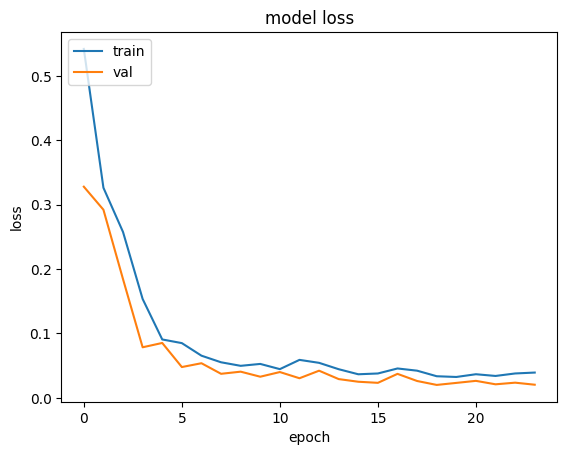

In [16]:
import matplotlib.pyplot as plt

plt.plot(df['loss'])
plt.plot(df['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')

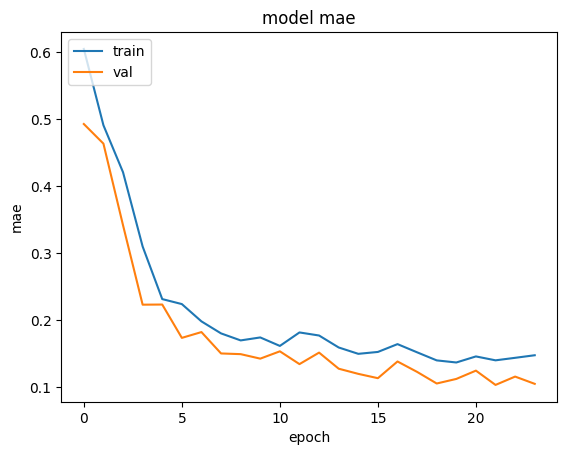

In [17]:
plt.plot(df['mae'])
plt.plot(df['val_mae'])
plt.title('model mae')
plt.ylabel('mae')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')

In [18]:
# ora l'istogramma dei residui

preds = model.predict(test)
preds.shape

12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 152ms/step


(360, 1)

In [22]:
y_true = np.concatenate([y for x, y in test], axis=0)
y_true.shape

(360,)

<Axes: >

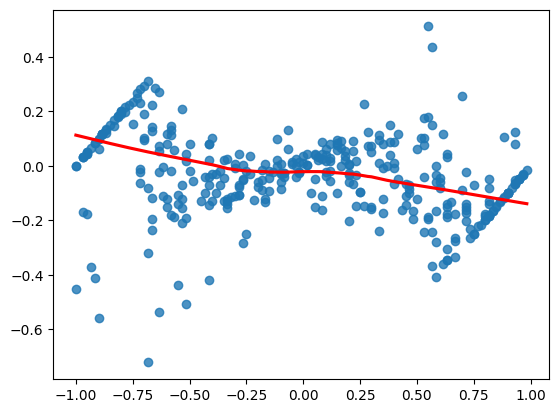

In [24]:
res = y_true - preds.flatten()
import seaborn as sns
sns.regplot(x=y_true, y=res, lowess=True, line_kws={'color': 'red'})